# Classical Time Series Analysis

So far in this course, we've worked with **cross-sectional data** — a collection of observations where each row is independent of the others. Shuffle the rows and nothing changes.

**Time series data is different.** The observations are ordered, and that order matters. Yesterday's stock price tells you something about today's. Last month's passenger count tells you something about this month's. The dependence between observations is not a problem to eliminate — it's the signal we want to model.

In this notebook we'll cover:
1. What makes time series data special
2. Stationarity and how to achieve it
3. Autocorrelation — the memory in a series
4. AR, MA, and ARIMA models
5. Fitting and forecasting with a real dataset
6. A brief look at seasonality

We will **not** cover recurrent neural networks or LSTMs here — those come later. Everything in this notebook is classical statistics, and it still works remarkably well.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

import ipywidgets as widgets
from IPython.display import display

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 1. What Is a Time Series?

A **time series** is a sequence of values indexed by time:

$$y_1, y_2, y_3, \ldots, y_T$$

The subscript is a time step, not a row number. The key modeling challenge is that $y_t$ and $y_{t-1}$ are **not independent** — and we want to exploit that dependence to predict $y_{t+1}$.

This breaks a core assumption of ordinary regression. If you fed a time series into a linear regression without accounting for time structure, the model would have no idea which observations came before which, and the standard errors would be wrong.

Let's load the classic airline passengers dataset and take a first look.

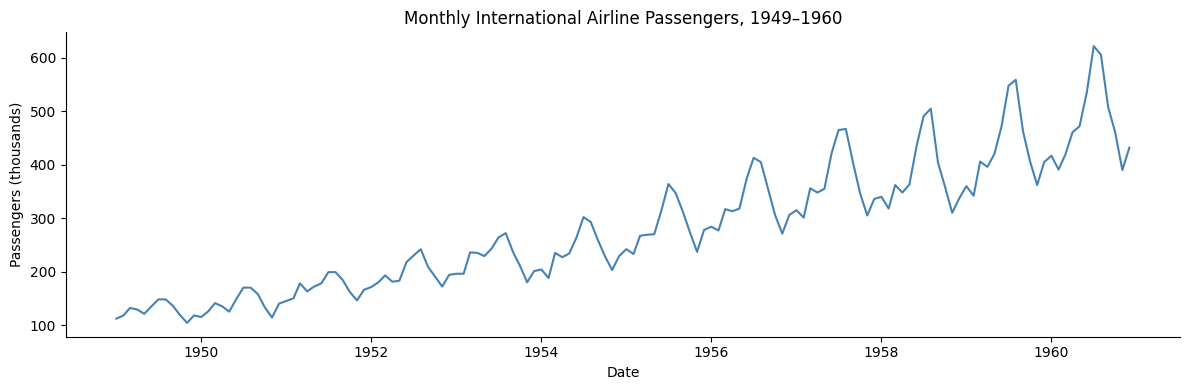

Series length: 144 monthly observations
Range: Jan 1949 to Dec 1960


In [2]:
raw = sm.datasets.get_rdataset("AirPassengers", "datasets").data
passengers = raw['value'].copy()
passengers.index = pd.date_range(start='1949-01', periods=len(passengers), freq='MS')
passengers.name = 'Passengers (thousands)'

fig, ax = plt.subplots()
ax.plot(passengers, color='steelblue', linewidth=1.5)
ax.set_title('Monthly International Airline Passengers, 1949–1960')
ax.set_ylabel('Passengers (thousands)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

print(f"Series length: {len(passengers)} monthly observations")
print(f"Range: {passengers.index[0].strftime('%b %Y')} to {passengers.index[-1].strftime('%b %Y')}")

Even before modeling, we can see three things in this plot:

- **Trend** — the series is generally increasing over time.
- **Seasonality** — there are regular spikes every summer and dips every winter.
- **Increasing variance** — the swings are getting larger as the level rises.

These are all violations of a property called **stationarity**, which most classical time series models require. We'll address each one.

## 2. Stationarity

A series is **stationary** if its statistical properties don't change over time:
- The mean is constant (no trend).
- The variance is constant (no spreading out).
- The autocorrelation structure depends only on the *lag*, not on *when* you are in the series.

Why does this matter? Classical models like ARIMA estimate fixed coefficients that describe how past values predict future values. If the series is non-stationary, those coefficients are meaningless — the relationship is different at different points in time.

### Variance stabilization with a log transform

When variance grows with the level of the series (as with airline passengers), taking the **natural log** compresses the scale and stabilizes variance. This is the first transformation we'll apply.

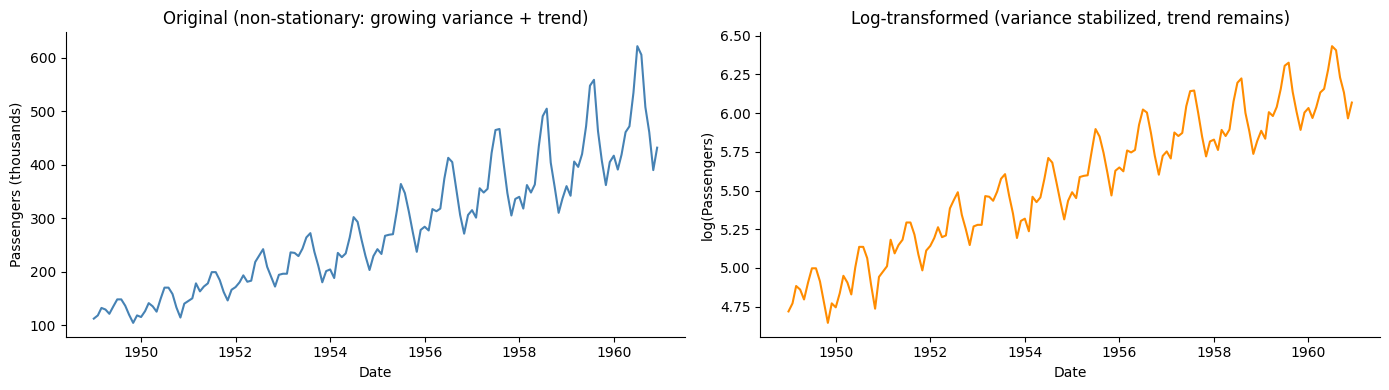

In [3]:
log_passengers = np.log(passengers)
log_passengers.name = 'log(Passengers)'

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(passengers, color='steelblue', linewidth=1.5)
axes[0].set_title('Original (non-stationary: growing variance + trend)')
axes[0].set_ylabel('Passengers (thousands)')

axes[1].plot(log_passengers, color='darkorange', linewidth=1.5)
axes[1].set_title('Log-transformed (variance stabilized, trend remains)')
axes[1].set_ylabel('log(Passengers)')

for ax in axes:
    ax.set_xlabel('Date')

plt.tight_layout()
plt.show()

### Removing the trend with differencing

The most common way to remove a trend is **first differencing**: replace each value with the change from the previous period.

$$\Delta y_t = y_t - y_{t-1}$$

If the series still has a trend after one round of differencing, you can difference again (**second differencing**). The number of times you difference to achieve stationarity is the **d** in ARIMA(p, d, q).

The **Augmented Dickey-Fuller (ADF) test** gives us a formal check. The null hypothesis is that the series has a unit root (non-stationary). A p-value below 0.05 means we can reject that — the series is likely stationary.

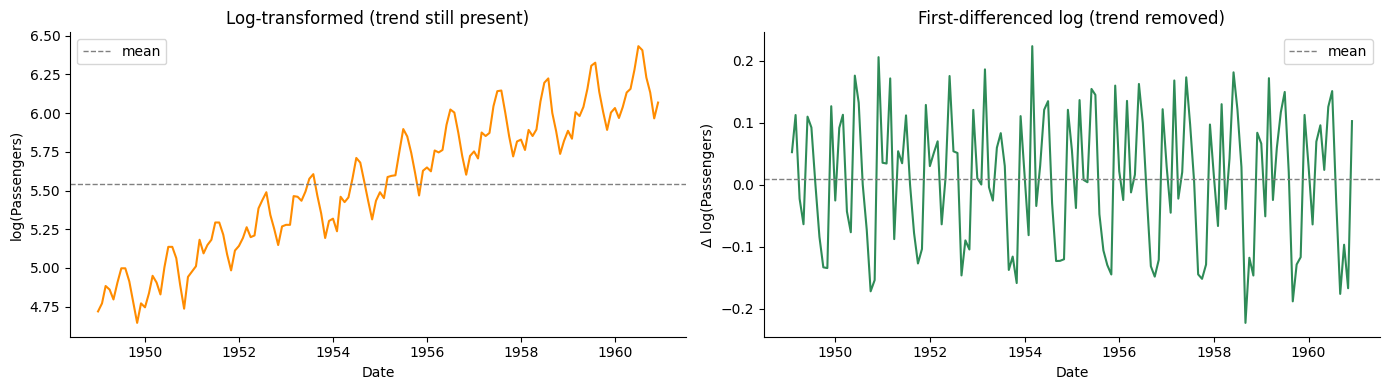

ADF test on log series:          p = 0.4224  ✗ non-stationary
ADF test on differenced series:  p = 0.0711  ✗ non-stationary


In [4]:
log_diff = log_passengers.diff().dropna()
log_diff.name = 'First difference of log(Passengers)'

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(log_passengers, color='darkorange', linewidth=1.5)
axes[0].set_title('Log-transformed (trend still present)')
axes[0].set_ylabel('log(Passengers)')
axes[0].axhline(log_passengers.mean(), color='gray', linestyle='--', linewidth=1, label='mean')
axes[0].legend()

axes[1].plot(log_diff, color='seagreen', linewidth=1.5)
axes[1].set_title('First-differenced log (trend removed)')
axes[1].set_ylabel('Δ log(Passengers)')
axes[1].axhline(log_diff.mean(), color='gray', linestyle='--', linewidth=1, label='mean')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('Date')

plt.tight_layout()
plt.show()

adf_original = adfuller(log_passengers)
adf_differenced = adfuller(log_diff)

print(f"ADF test on log series:          p = {adf_original[1]:.4f}  {'✓ stationary' if adf_original[1] < 0.05 else '✗ non-stationary'}")
print(f"ADF test on differenced series:  p = {adf_differenced[1]:.4f}  {'✓ stationary' if adf_differenced[1] < 0.05 else '✗ non-stationary'}")

After one round of differencing, the ADF test should reject the unit root hypothesis, confirming that d = 1 is sufficient to remove the trend.

The differenced series still shows a seasonal pattern — we'll address that later. For now, let's study the memory structure of the series.

## 3. Autocorrelation

**Autocorrelation** is the correlation of a series with a lagged version of itself. The correlation between $y_t$ and $y_{t-k}$ is the autocorrelation at lag $k$.

Two plots are indispensable for time series modeling:

- **ACF (AutoCorrelation Function)**: Shows the correlation between the series and each of its lags. A long, slowly-decaying ACF tells you the series has a long memory — AR terms are present.

- **PACF (Partial AutoCorrelation Function)**: Shows the *direct* effect of each lag, after removing the influence of all shorter lags. This is like asking: "Does lag 3 matter, above and beyond what lags 1 and 2 already explain?"

The shaded region in each plot is the 95% confidence band. Bars that extend beyond it are statistically significant.

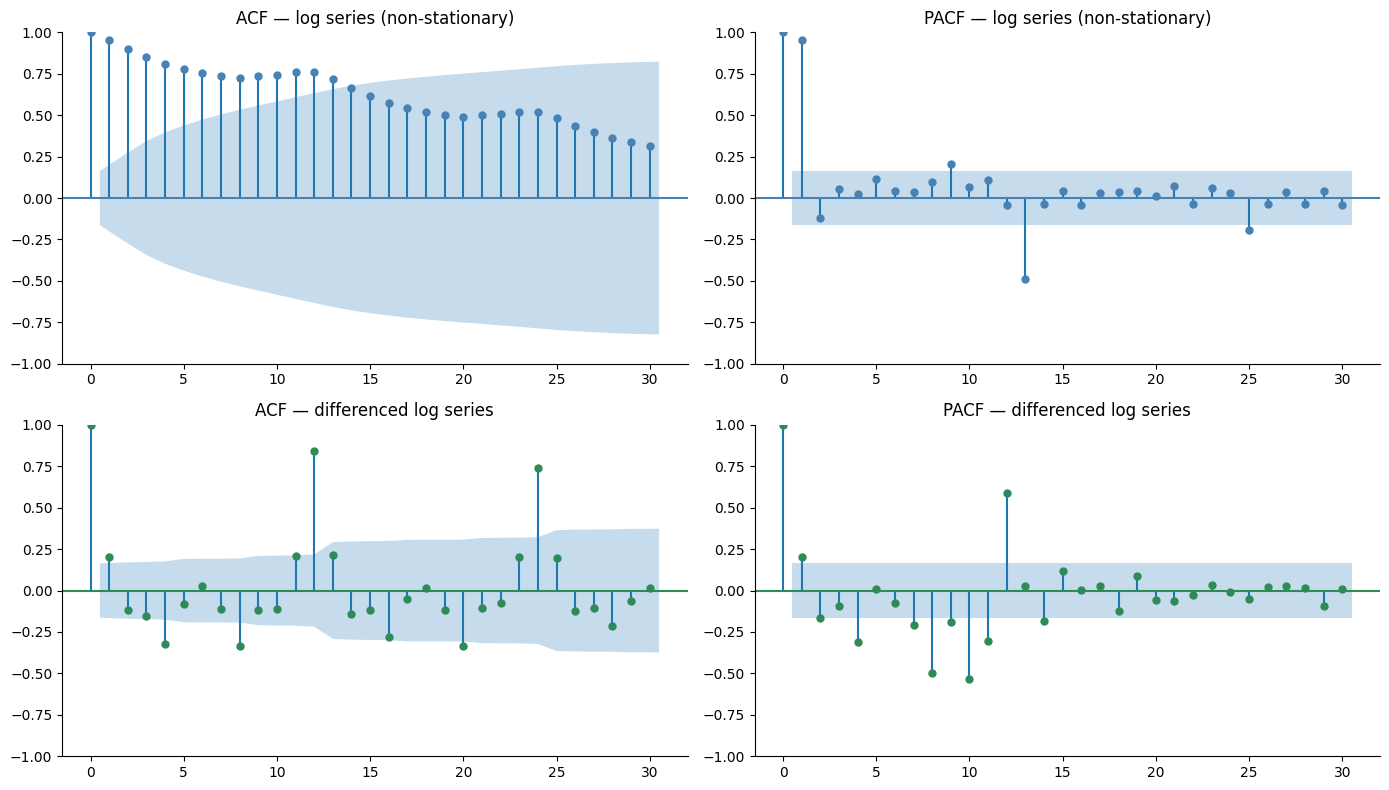

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(log_passengers, lags=30, ax=axes[0, 0], color='steelblue', title='ACF — log series (non-stationary)')
plot_pacf(log_passengers, lags=30, ax=axes[0, 1], color='steelblue', title='PACF — log series (non-stationary)')
plot_acf(log_diff, lags=30, ax=axes[1, 0], color='seagreen', title='ACF — differenced log series')
plot_pacf(log_diff, lags=30, ax=axes[1, 1], color='seagreen', title='PACF — differenced log series')

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**How to read these plots:**

- The non-stationary log series (top row) shows an ACF that decays very slowly — a classic sign of a trend. This series violates the stationarity assumption badly.

- The differenced series (bottom row) shows much faster decay. The spikes at lags 12, 24 in the ACF are the seasonal pattern — every 12 months, the pattern repeats.

- The PACF of the differenced series cuts off more sharply, which helps us identify how many AR terms to include.

**Rule of thumb for choosing p and q:**
- The ACF tells you **q** — if the ACF cuts off sharply after lag q, that's the MA order.
- The PACF tells you **p** — if the PACF cuts off sharply after lag p, that's the AR order.
- When both decay gradually, an ARMA model (both AR and MA terms) is likely appropriate.

## 4. The AR(p) Model — AutoRegressive

The **autoregressive model of order p** says: the current value is a weighted sum of the last p values, plus noise.

$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t$$

where $\varepsilon_t$ is white noise (mean zero, constant variance, uncorrelated over time).

This looks exactly like linear regression — the predictors are just lagged values of the same series. The $\phi$ coefficients measure how strongly each lag contributes.

**Intuition:** An AR(1) model with $\phi_1 = 0.9$ means "today's value is 90% of yesterday's value, plus some random shock." The series has long memory. If $\phi_1 = 0.1$, the series forgets the past quickly.

**How to choose p:** Look at the PACF. The order p is approximately where the PACF drops into the confidence band.

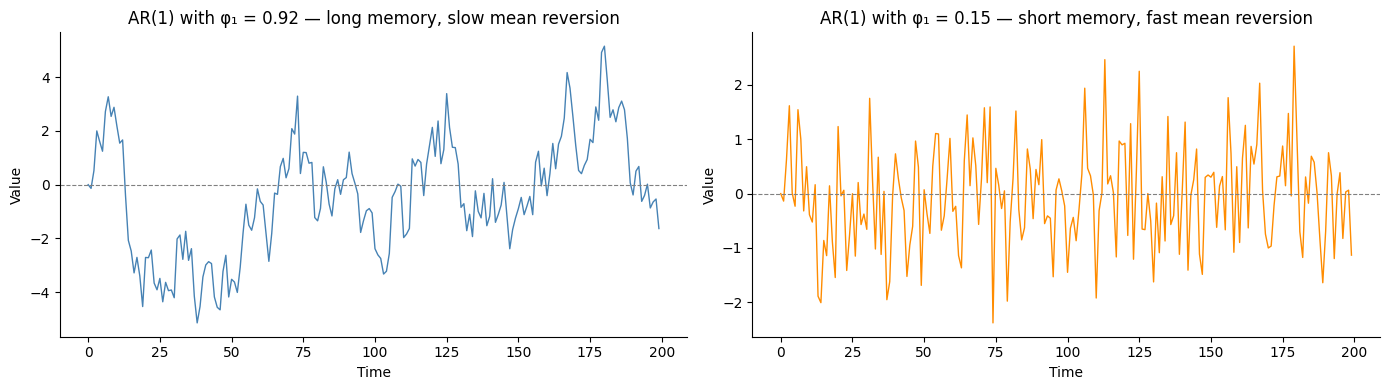

In [6]:
np.random.seed(42)
n = 200
noise = np.random.normal(0, 1, n)

ar1_strong = np.zeros(n)
ar1_weak = np.zeros(n)

for t in range(1, n):
    ar1_strong[t] = 0.92 * ar1_strong[t-1] + noise[t]
    ar1_weak[t]   = 0.15 * ar1_weak[t-1]   + noise[t]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ar1_strong, color='steelblue', linewidth=1)
axes[0].set_title('AR(1) with φ₁ = 0.92 — long memory, slow mean reversion')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)

axes[1].plot(ar1_weak, color='darkorange', linewidth=1)
axes[1].set_title('AR(1) with φ₁ = 0.15 — short memory, fast mean reversion')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)

for ax in axes:
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

## 5. The MA(q) Model — Moving Average

The **moving average model of order q** says: the current value is a weighted sum of past *forecast errors* (residuals), plus noise.

$$y_t = c + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \cdots + \theta_q \varepsilon_{t-q}$$

The $\varepsilon_{t-k}$ terms are past shocks — the surprises the model didn't anticipate. An MA model says "what happens today depends on how wrong I was in the recent past."

This is **not** the same as a rolling average of the series itself. It's a model based on past prediction errors.

**Key properties:**
- An MA(q) model has memory of exactly q steps. Beyond lag q, there is no autocorrelation.
- The ACF of an MA(q) process cuts off sharply at lag q — that's the signature to look for.

**How to choose q:** Look at the ACF of the stationary series. The order q is approximately where the ACF drops into the confidence band.

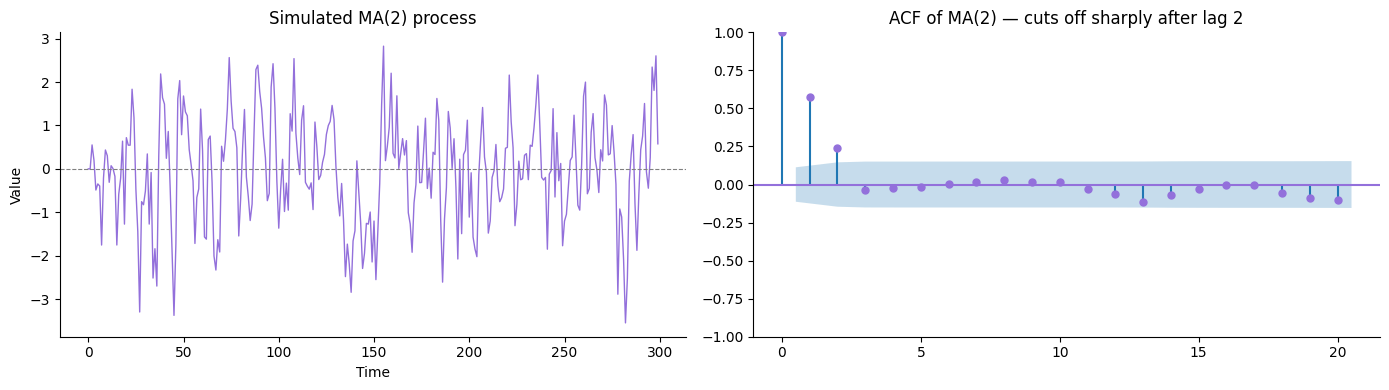

Notice: the ACF is significant at lags 1 and 2, then drops inside the confidence band.
This is the diagnostic signature of an MA(2) process.


In [7]:
np.random.seed(7)
n = 300
eps = np.random.normal(0, 1, n)

ma2 = np.zeros(n)
for t in range(2, n):
    ma2[t] = eps[t] + 0.7 * eps[t-1] + 0.5 * eps[t-2]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ma2, color='mediumpurple', linewidth=1)
axes[0].set_title('Simulated MA(2) process')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Value')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)

plot_acf(ma2, lags=20, ax=axes[1], color='mediumpurple',
         title='ACF of MA(2) — cuts off sharply after lag 2')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("Notice: the ACF is significant at lags 1 and 2, then drops inside the confidence band.")
print("This is the diagnostic signature of an MA(2) process.")

## 6. ARIMA(p, d, q) — Putting It Together

**ARIMA** combines three components:

| Letter | Name | What it does |
|--------|------|--------------|
| **AR(p)** | AutoRegressive | Uses the last p values as predictors |
| **I(d)** | Integrated | Differences the series d times to achieve stationarity |
| **MA(q)** | Moving Average | Uses the last q forecast errors as predictors |

The full model operates on the **differenced** series. If d = 1, the model is:

$$\Delta y_t = c + \phi_1 \Delta y_{t-1} + \cdots + \phi_p \Delta y_{t-p} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$$

**Choosing p, d, q:**
1. **d** — difference until the ADF test says the series is stationary. Usually 0 or 1.
2. **p** — look at the PACF of the differenced series. Count significant lags.
3. **q** — look at the ACF of the differenced series. Count significant lags.

When in doubt, try a few candidate (p, d, q) combinations and compare **AIC** (Akaike Information Criterion). Lower AIC is better.

In [8]:
candidate_orders = [
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2),
]

print(f"{'Order (p,d,q)':<18} {'AIC':>10} {'BIC':>10}")
print("-" * 42)

aic_results = {}
for order in candidate_orders:
    try:
        m = ARIMA(log_passengers, order=order).fit()
        aic_results[order] = m.aic
        print(f"ARIMA{str(order):<13} {m.aic:>10.2f} {m.bic:>10.2f}")
    except Exception as e:
        print(f"ARIMA{str(order):<13} {'failed':>10}")

best_order = min(aic_results, key=aic_results.get)
print(f"\nBest order by AIC: ARIMA{best_order}")

Order (p,d,q)             AIC        BIC
------------------------------------------
ARIMA(0, 1, 1)        -238.73    -232.80
ARIMA(1, 1, 0)        -236.60    -230.67
ARIMA(1, 1, 1)        -242.63    -233.74
ARIMA(2, 1, 1)        -251.46    -239.61
ARIMA(1, 1, 2)        -248.86    -237.01
ARIMA(2, 1, 2)        -247.78    -232.97

Best order by AIC: ARIMA(2, 1, 1)


## 7. Fitting ARIMA and Forecasting — Airline Passengers

Let's fit ARIMA(1, 1, 1) on the log-transformed series. We'll hold out the last 24 months as a test set, fit on the training data, and forecast forward.

Forecasts come with **confidence intervals** — the further out we predict, the wider the interval gets. This is the model being honest about uncertainty growing over time.

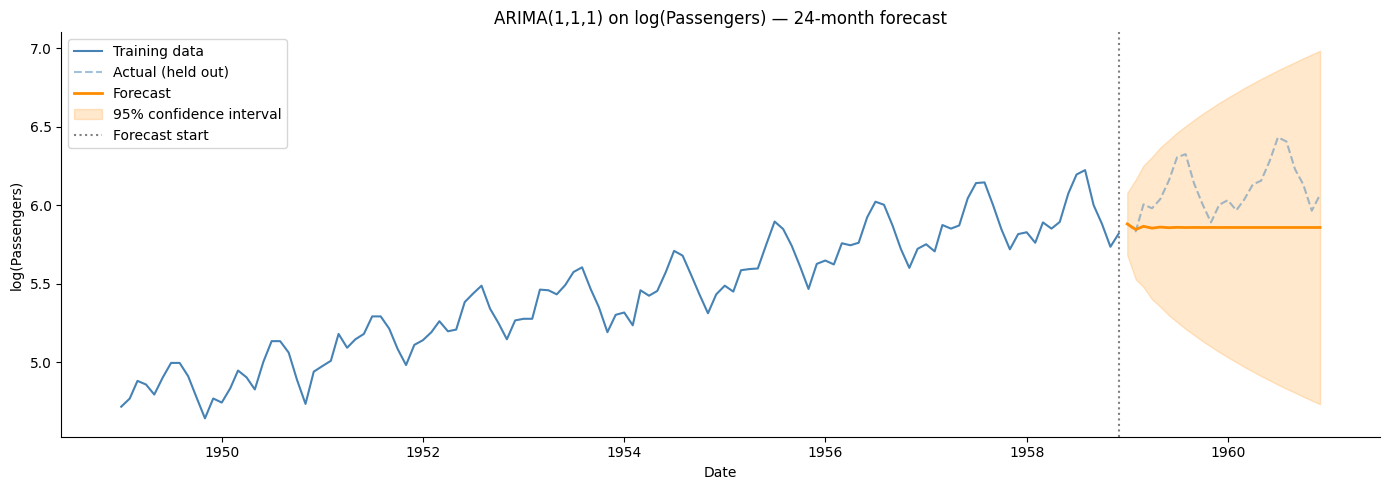

ARIMA(1,1,1) — AIC: -201.68   RMSE on held-out 24 months: 0.2893 (log scale)

Model summary:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5761      0.191     -3.014      0.003      -0.951      -0.201
ma.L1          0.8347      0.117      7.131      0.000       0.605       1.064
sigma2         0.0102      0.002      5.556      0.000       0.007       0.014


In [9]:
HOLDOUT = 24
train = log_passengers.iloc[:-HOLDOUT]
test  = log_passengers.iloc[-HOLDOUT:]

model = ARIMA(train, order=(1, 1, 1)).fit()

forecast_result = model.get_forecast(steps=HOLDOUT)
forecast_mean   = forecast_result.predicted_mean
conf_int        = forecast_result.conf_int(alpha=0.05)

forecast_mean.index = test.index
conf_int.index      = test.index

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train, color='steelblue', linewidth=1.5, label='Training data')
ax.plot(test,  color='steelblue', linewidth=1.5, linestyle='--', alpha=0.5, label='Actual (held out)')
ax.plot(forecast_mean, color='darkorange', linewidth=2, label='Forecast')
ax.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='darkorange', alpha=0.2, label='95% confidence interval'
)

ax.axvline(train.index[-1], color='gray', linestyle=':', linewidth=1.5, label='Forecast start')
ax.set_title('ARIMA(1,1,1) on log(Passengers) — 24-month forecast')
ax.set_ylabel('log(Passengers)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean((forecast_mean.values - test.values) ** 2))
print(f"ARIMA(1,1,1) — AIC: {model.aic:.2f}   RMSE on held-out 24 months: {rmse:.4f} (log scale)")
print(f"\nModel summary:")
print(model.summary().tables[1])

The forecast captures the overall trend, but notice it doesn't reproduce the seasonal spikes. That's expected — ARIMA doesn't model seasonality. The confidence interval grows over time, reflecting genuine uncertainty about the distant future.

For the seasonal pattern, we need SARIMA — covered briefly below.

## 8. Interactive ARIMA Explorer

Use the sliders below to change the ARIMA order. The model refits on the full log-transformed series and plots:
- **In-sample fit** (what the model thinks it saw)
- **24-step forecast** with 95% confidence interval
- **AIC** in the title (lower = better fit, penalized for complexity)

Try:
- d = 0 vs d = 1 to see what happens with non-stationary data.
- High p or q values to see overfitting.
- p = 1, d = 1, q = 1 as a reasonable baseline.

In [10]:
p_slider = widgets.IntSlider(value=1, min=0, max=4, step=1, description='p (AR):')
d_slider = widgets.IntSlider(value=1, min=0, max=2, step=1, description='d (I):')
q_slider = widgets.IntSlider(value=1, min=0, max=4, step=1, description='q (MA):')

out = widgets.Output()

def update_arima(p, d, q):
    out.clear_output(wait=True)
    with out:
        try:
            m = ARIMA(log_passengers, order=(p, d, q)).fit()
            fcast = m.get_forecast(steps=24)
            fmean = fcast.predicted_mean
            ci    = fcast.conf_int(alpha=0.05)

            last_date = log_passengers.index[-1]
            future_index = pd.date_range(
                start=last_date + pd.DateOffset(months=1),
                periods=24, freq='MS'
            )
            fmean.index = future_index
            ci.index    = future_index

            fitted_vals = m.fittedvalues

            fig, ax = plt.subplots(figsize=(13, 5))

            ax.plot(log_passengers, color='steelblue', linewidth=1.5, label='Observed')
            ax.plot(fitted_vals, color='seagreen', linewidth=1, linestyle='--',
                    alpha=0.8, label='In-sample fit')
            ax.plot(fmean, color='darkorange', linewidth=2, label='24-step forecast')
            ax.fill_between(
                ci.index, ci.iloc[:, 0], ci.iloc[:, 1],
                color='darkorange', alpha=0.2, label='95% CI'
            )
            ax.axvline(log_passengers.index[-1], color='gray',
                       linestyle=':', linewidth=1.5, label='Forecast start')

            ax.set_title(f'ARIMA({p},{d},{q})   AIC = {m.aic:.2f}')
            ax.set_ylabel('log(Passengers)')
            ax.set_xlabel('Date')
            ax.legend(loc='upper left')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Could not fit ARIMA({p},{d},{q}): {e}")
            print("Try a different combination.")

interactive_plot = widgets.interactive(update_arima, p=p_slider, d=d_slider, q=q_slider)

controls = widgets.HBox([p_slider, d_slider, q_slider])
display(controls, out)
update_arima(1, 1, 1)

Output()

## 9. Seasonality and SARIMA

The airline passenger data has strong **seasonality** — a repeating pattern every 12 months. ARIMA doesn't model this; its differencing and lag structure only work at the scale of individual time steps.

**SARIMA** (Seasonal ARIMA) extends ARIMA by adding a second set of AR, I, and MA terms that operate at the seasonal frequency. The notation is:

$$\text{SARIMA}(p, d, q)(P, D, Q)_s$$

where:
- $(p, d, q)$ — the non-seasonal part, same as before
- $(P, D, Q)$ — seasonal AR order, seasonal differencing, seasonal MA order
- $s$ — the seasonal period (12 for monthly data, 4 for quarterly, etc.)

**Seasonal differencing** at period s: $\Delta_s y_t = y_t - y_{t-s}$. For monthly data, this is subtracting last year's value from this year's — eliminating the annual cycle.

**In `statsmodels`**, SARIMA is available as `SARIMAX` (the X is for optional exogenous variables):

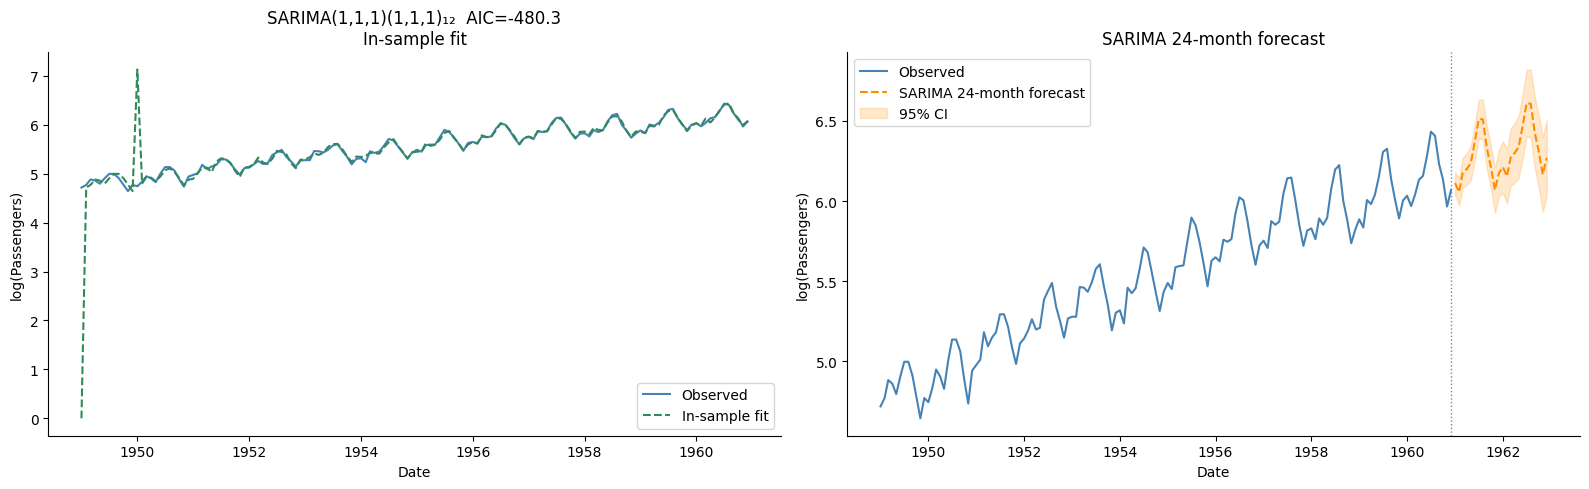

ARIMA(1,1,1)          AIC: -201.68
SARIMA(1,1,1)(1,1,1)₁₂  AIC: -480.30

The seasonal model captures the summer spikes that plain ARIMA misses.


In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    log_passengers,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
).fit(disp=False)

sarima_forecast = sarima_model.get_forecast(steps=24)
sf_mean = sarima_forecast.predicted_mean
sf_ci   = sarima_forecast.conf_int(alpha=0.05)

future_idx = pd.date_range(
    start=log_passengers.index[-1] + pd.DateOffset(months=1),
    periods=24, freq='MS'
)
sf_mean.index = future_idx
sf_ci.index   = future_idx

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (fmean, fci, title, color) in zip(axes, [
    (sarima_model.fittedvalues, None, f'SARIMA(1,1,1)(1,1,1)₁₂  AIC={sarima_model.aic:.1f}\nIn-sample fit', 'seagreen'),
    (sf_mean, sf_ci, 'SARIMA 24-month forecast', 'darkorange'),
]):
    ax.plot(log_passengers, color='steelblue', linewidth=1.5, label='Observed')
    ax.plot(fmean, color=color, linewidth=1.5, linestyle='--', label=title.split('\n')[-1])
    if fci is not None:
        ax.fill_between(fci.index, fci.iloc[:, 0], fci.iloc[:, 1],
                        color=color, alpha=0.2, label='95% CI')
        ax.axvline(log_passengers.index[-1], color='gray', linestyle=':', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('log(Passengers)')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"ARIMA(1,1,1)          AIC: {model.aic:.2f}")
print(f"SARIMA(1,1,1)(1,1,1)₁₂  AIC: {sarima_model.aic:.2f}")
print("\nThe seasonal model captures the summer spikes that plain ARIMA misses.")

## Summary

Here's what we covered:

| Concept | Key idea |
|---------|----------|
| **Time series** | Ordered, dependent observations — shuffling breaks the data |
| **Stationarity** | Constant mean and variance; required by classical models |
| **Differencing** | Subtract the previous value to remove trend; repeat d times |
| **ACF** | Autocorrelation at each lag; decays slowly for AR, cuts off for MA |
| **PACF** | Direct effect of each lag; cuts off sharply for AR |
| **AR(p)** | Weighted sum of last p observed values |
| **MA(q)** | Weighted sum of last q forecast errors |
| **ARIMA(p,d,q)** | AR + differencing + MA; fit with AIC comparison |
| **SARIMA** | Adds seasonal AR/MA/differencing terms at period s |

**What comes next:** Neural approaches (RNNs, LSTMs, and Transformers) handle non-linear time dependencies and multivariate series, but they require far more data and are harder to interpret. For many practical forecasting tasks — economic indicators, inventory planning, demand forecasting — ARIMA and SARIMA remain competitive and produce calibrated uncertainty estimates out of the box.